# 05 — A5: fine-tuned self-supervised speech Transformer (XLS-R), rounds R1 and R2

**Owner:** M4 · **Plan:** Phases 5–6 · **Split:** frozen 70/15/15 (hash `b74d294f…`). Models are selected on **validation**. The test split is not touched until Phase 7.

**Model.** `src/models/wav2vec2.py` wraps Hugging Face's `Wav2Vec2ForSequenceClassification`.
- It reads the **raw 16 kHz waveform** of the same centred energy window that A1–A4 use.
- A convolutional feature encoder turns the waveform into one vector per 20 ms.
- A Transformer relates every frame to every other with self-attention. Unlike A3 (recurrence) and A4 (stacked convolutions), every frame can see the whole word at once. Order enters through a convolutional positional embedding.
- The frames are projected to 256 dimensions, mean-pooled over time and classified.

**Pretraining.** The default backbone is **XLS-R-300M** (Babu et al., 2022). It was pretrained without labels on 436K hours of speech in 128 languages. Only 91 of those hours (about 0.02%) are Swahili, so A5 mostly tests transfer from other languages. R2 compares it with **wav2vec2-base** (Baevski et al., 2020): 95M parameters, pretrained only on 960 hours of English audiobooks.

**Training.** The same loop, loss, early-stopping rule and calibration as A3 and A4 (`src/train_torch.py`), so the comparison is like for like:
- The convolutional feature encoder stays frozen, as is standard, and the Transformer is fine-tuned at a peak learning rate of 3e-5. The new, randomly initialised head learns at 1e-3.
- One-cycle schedule with 10% warm-up, 10 epochs, batch 16, label smoothing 0.1. The epoch with the lowest validation log loss is kept.
- Both backbones get the same fine-tuning regularisation: time masking of 10-frame spans with probability 0.05, no LayerDrop.

**The bar** (validation, seed-42 runs; mean ± SD over three seeds where available):

| Model | Accuracy | Log loss |
|---|---|---|
| A1 (order-free) | 77.9% | 0.725 |
| A2 (HMM) | 95.2% | 0.180 |
| A3 (BiLSTM + attention) | 97.0% | 0.134 (seeds: 0.137 ± 0.004) |
| A4 (TC-ResNet) | 97.1% | 0.119 (seeds: 0.135 ± 0.023) |

**Compute.** Train on a GPU (Kaggle T4, ~1 min per epoch for XLS-R). `RERUN = False` reuses logged runs, so re-executing the notebook takes seconds anywhere and needs no GPU. Checkpoints (1.2 GB each for XLS-R) are saved only for the final seed runs, which Phase 7 scores on the test split.

In [1]:
import glob, os, shutil, sys, subprocess

REPO_URL = "https://github.com/Hassan-Adelani-Luqman/nlp-sequential-modeling-group21.git"
REPO_DIR = "nlp-sequential-modeling-group21"
if os.path.isdir("/kaggle/input") or "google.colab" in sys.modules:
    # A code-snapshot dataset attached on Kaggle takes precedence over GitHub (lets you run code before it is pushed).
    snapshot = glob.glob("/kaggle/input/**/src/train_torch.py", recursive=True) if os.path.isdir("/kaggle/input") else []
    zipped = glob.glob("/kaggle/input/**/group21-code*.zip", recursive=True) if os.path.isdir("/kaggle/input") else []
    if not snapshot and zipped:  # the archive was not unpacked on upload: unpack it ourselves
        import zipfile
        zipfile.ZipFile(zipped[0]).extractall("/tmp/snapshot")
        snapshot = glob.glob("/tmp/snapshot/**/src/train_torch.py", recursive=True)
    if snapshot:
        REPO_DIR = "/tmp/" + REPO_DIR   # outside /kaggle/working, so only results are saved as outputs
        if not os.path.isdir(REPO_DIR):
            shutil.copytree(os.path.dirname(os.path.dirname(snapshot[0])), REPO_DIR)
        print("using code snapshot:", os.path.dirname(os.path.dirname(snapshot[0])))
    elif not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "-q", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
    if os.path.isdir("/kaggle/working"):
        # Kaggle writes outputs to /kaggle/working, which starts empty: seed it with the repo's logged runs
        # (and any checkpoints shipped with the code snapshot) so finished runs are reused, not retrained.
        for folder in ("results", "checkpoints"):
            if os.path.isdir(folder):
                shutil.copytree(folder, os.path.join("/kaggle/working", folder), dirs_exist_ok=True)
        os.environ.setdefault("SWN_CACHE_DIR", "/tmp/swn_feature_cache")  # recomputable: keep it out of the outputs
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

In [2]:
# Fail fast with a clear message if an out-of-date code snapshot or clone is in use
assert os.path.exists("src/models/wav2vec2.py"), "src/models/wav2vec2.py is missing: the attached code snapshot (or clone) is out of date"
import copy, gc, json, platform
import numpy as np, pandas as pd, torch, yaml
import matplotlib.pyplot as plt
from IPython.display import display
import transformers

from src.augment import WaveAugment
from src.data import label_names, load_splits
from src.evaluate import (KEY_PAIRS, compute_metrics, cross_fitted_temperature, load_predictions, pair_confusion,
                          plot_confusion_matrix, plot_learning_curves)
from src.experiment import ExperimentRunner
from src.features import cached_features
from src.models.wav2vec2 import Wav2Vec2Classifier, count_all_parameters, tiny_config
from src.paths import CONFIGS_DIR, REPO_ROOT, checkpoints_dir, results_dir
from src.plotting import INK_SECONDARY, MODEL_COLORS, apply_style, progression_chart, save_figure
from src.train_torch import TrainConfig, train_model
from src.utils import build_experiment_table, get_device, gpu_name, set_seed
assert "standardize" in TrainConfig.__dataclass_fields__, "src/train_torch.py predates raw-waveform training"

transformers.logging.set_verbosity_error()   # hides the expected "newly initialised head" notice
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
RERUN = False   # True = retrain every run and overwrite its log; False = reuse runs that are already logged
SEED, MEMBER, NOTEBOOK = 42, "M4", "notebooks/05_xlsr.ipynb"
SMOKE = os.environ.get("SWN_SMOKE") == "1"   # tiny end-to-end check with a small random wav2vec 2.0 (use with SWN_OUTPUT_DIR)
set_seed(SEED)
apply_style()
torch.set_num_threads(os.cpu_count() or 4)

NAMES = label_names()
splits = load_splits()
train, val = splits["train"], splits["val"]
if SMOKE:
    take = lambda df, n: df.groupby("label_id", group_keys=False).head(n).reset_index(drop=True)
    train, val = take(train, 4), take(val, 5)          # 5 per word: the minimum for cross-fitted calibration
y_tr, y_val = train.label_id.to_numpy(), val.label_id.to_numpy()
DEVICE = get_device()
NUM_WORKERS = 2 if (os.path.isdir("/kaggle/input") or "google.colab" in sys.modules) else 0
runner = ExperimentRunner(val, NAMES, member=MEMBER, notebook=NOTEBOOK, seed=SEED, rerun=RERUN)
print(f"train {len(train)} · val {len(val)} · device {gpu_name()} · Python {platform.python_version()} · "
      f"torch {torch.__version__} · transformers {transformers.__version__}")

C:\Users\Luqma\dev\projects\coursework\nlp-sequential-modeling-group21\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


train 2940 · val 630 · device cpu · Python 3.14.3 · torch 2.14.0+cpu · transformers 5.18.0


In [3]:
def augmenter(kind, seed=SEED):
    '''Augmentation policy by name: "wave" = time shift, speed perturbation and noise on the raw waveform.'''
    if kind == "none":
        return None
    if kind == "wave":
        return WaveAugment(seed=seed)
    raise ValueError(kind)


def build_a5(model_cfg):
    '''The A5 network. Smoke runs swap the pretrained backbone for a tiny random one (no 1.2 GB download).'''
    if SMOKE:
        return Wav2Vec2Classifier(config=tiny_config(), **{k: v for k, v in model_cfg.items() if k != "backbone"})
    return Wav2Vec2Classifier(**model_cfg)


def a5_fit_predict(exp_id, cfg, seed=SEED, save_checkpoint=False):
    '''Train one configuration; return temperature-scaled val probabilities and run details.'''
    def fit_predict():
        feat = cfg["features"]
        X_tr, X_va = cached_features(train, **feat), cached_features(val, **feat)
        train_cfg = TrainConfig(**{**cfg["train"], "seed": seed, "num_workers": NUM_WORKERS, "standardize": False,
                                   "eval_batch_size": 32, **({"epochs": 1} if SMOKE else {})})
        result = train_model(lambda: build_a5(cfg["model"]), X_tr, y_tr, X_va, y_val, train_cfg,
                             augment=augmenter(cfg["augment"], seed), device=DEVICE,
                             checkpoint=checkpoints_dir() / f"{exp_id}_seed{seed}.pt" if save_checkpoint else None)
        probs, temperature = cross_fitted_temperature(result.val_logits, y_val, seed=seed)
        total, trainable = count_all_parameters(result.model)
        extra = {"best_epoch": result.best_epoch, "epochs_run": int(len(result.history)), "temperature": temperature,
                 "n_params": total, "n_trainable": trainable, "history": result.history}
        if result.model.layer_weights() is not None:
            extra["layer_weights"] = result.model.layer_weights()
        del result
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()    # free the GPU for the next 300M-parameter model
        return probs, extra
    return fit_predict


DEFAULT = {
    "features": {"feature": "wave", "crop": "energy", "seconds": 1.5},       # (24000,) samples at 16 kHz
    "model": {"backbone": "xlsr-300m", "freeze": "feature_encoder", "head_lr": 1e-3, "weighted_layer_sum": False,
              "mask_time_prob": 0.05, "layerdrop": 0.0},
    "train": {"epochs": 10, "batch_size": 16, "lr": 3e-5, "patience": 10},   # patience 10: all epochs, best one kept
    "augment": "none",
}

## R1 — default configuration

A5-R1-01 [reused] log loss 0.111 · acc 97.8% · macro-F1 0.978 · ECE 0.016 · tisa/sita 1.0% · 13.7 min


best epoch 5 of 10 · 315,704,204 parameters (311,494,028 trained) · temperature 0.73


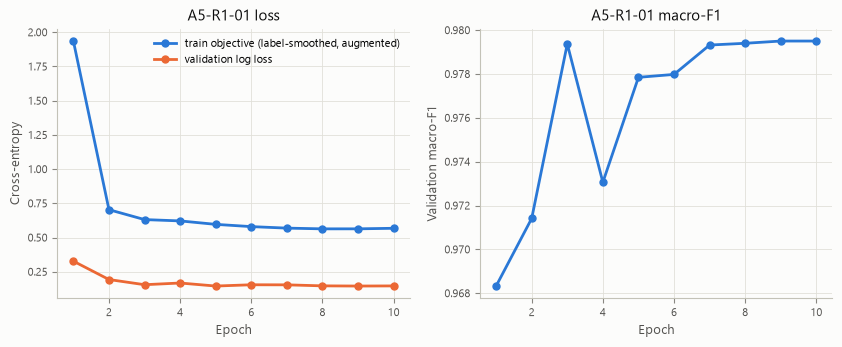

In [4]:
r1 = runner.run("A5-R1-01", "first A5 run: XLS-R-300M fine-tuned on the raw waveform (feature encoder frozen), no augmentation",
                "default configuration from Plan.md Phase 5", a5_fit_predict("A5-R1-01", DEFAULT), copy.deepcopy(DEFAULT))
print(f"best epoch {r1['extra']['best_epoch']} of {r1['extra']['epochs_run']} · {r1['extra']['n_params']:,} parameters "
      f"({r1['extra']['n_trainable']:,} trained) · temperature {r1['extra']['temperature']:.2f}")
axes = plot_learning_curves(r1["extra"]["history"], title="A5-R1-01")
save_figure(axes[0].figure, "a5_r1_learning_curves")
plt.show()

**Observations → next step (A5, R1)**
- **Pretraining wins before any tuning.** The default run reaches log loss 0.111 and 97.8% accuracy (ECE 0.016), with no augmentation. That already beats the *tuned* A4 (0.119, 97.1%) and A3 (0.134, 97.0%).
- **It learns in a few epochs.** Validation macro-F1 is 96.8% after the first epoch, and the best epoch is 5 of 10. After that the validation loss stays flat (0.146–0.155 before calibration), so there is no over-fitting, even though 311.5M parameters are trained on 2,940 clips. The pretrained weights act as a strong prior.
- **It is expensive.** One epoch takes 76 s on the T4 and the run 13.7 min, against about 1 min for a whole A4 run. The model has 315.7M parameters; only the 4.2M of the convolutional feature encoder stay frozen.
- **→ Next:** R2 tests the pretraining language, the fine-tuning depth, augmentation, the window length, the layer weighting and the learning rate.

## R2 — greedy one-factor-at-a-time search
Each step changes one factor of the **current best** configuration, and the change is kept only if validation log loss improves.

| Run | Change | Question |
|---|---|---|
| 01 | wav2vec2-base instead of XLS-R-300M | Does multilingual pretraining (Swahili included) transfer better than English-only pretraining? The base model is also 3× smaller. |
| 02 | Frozen encoder: train only the head | How much does fine-tuning the Transformer add, and at what cost? |
| 03 | Waveform augmentation (shift, speed 0.9–1.1×, noise) | Does the synthetic variation that helped A4 also help a pretrained model? |
| 04 / 05 | 1.0 s / 2.0 s window | How much context does self-attention need? (A3 was flat; A4 wanted 2.0 s.) |
| 06 | Weighted sum of all Transformer layers | Is word identity clearer in the middle layers than in the last one? (As in the SUPERB benchmark.) |
| 07 / 08 | Encoder learning rate 1e-5 / 5e-5 | Sensitivity to the fine-tuning learning rate |

In [5]:
best_cfg, best_run = copy.deepcopy(DEFAULT), r1
decisions = []


def try_change(exp_id, change, rationale, **overrides):
    '''Run the current best configuration with one change; keep the change if val log loss improves.'''
    global best_cfg, best_run
    cfg = copy.deepcopy(best_cfg)
    for section, values in overrides.items():
        cfg[section] = values if not isinstance(values, dict) else {**cfg[section], **values}
    r = runner.run(exp_id, change, rationale, a5_fit_predict(exp_id, cfg), cfg)
    kept = r["metrics"]["log_loss"] < best_run["metrics"]["log_loss"]
    decisions.append({"exp_id": exp_id, "change": change, "val_logloss": r["metrics"]["log_loss"],
                      "best_before": best_run["metrics"]["log_loss"], "kept": kept})
    if kept:
        best_cfg, best_run = cfg, r
    print(f"   → {'KEPT' if kept else 'rejected'} (current best: {best_run['exp_id']}, "
          f"log loss {best_run['metrics']['log_loss']:.3f})")


try_change("A5-R2-01", "wav2vec2-base (95M, English-only pretraining) instead of XLS-R-300M (128 languages incl. Swahili)",
           "does multilingual pretraining transfer better to Swahili?", model={"backbone": "wav2vec2-base"})
try_change("A5-R2-02", "frozen encoder: train only the classification head", "what does fine-tuning the Transformer add?",
           model={"freeze": "encoder"})
try_change("A5-R2-03", "+ waveform augmentation: time shift, speed 0.9-1.1x, noise at 10-30 dB SNR",
           "the synthetic variation that helped A4 (no external data allowed)", augment="wave")

A5-R2-01 [reused] log loss 0.120 · acc 97.5% · macro-F1 0.975 · ECE 0.020 · tisa/sita 1.0% · 5.7 min


   → rejected (current best: A5-R1-01, log loss 0.111)
A5-R2-02 [reused] log loss 1.960 · acc 27.1% · macro-F1 0.233 · ECE 0.075 · tisa/sita 10.5% · 4.8 min


   → rejected (current best: A5-R1-01, log loss 0.111)
A5-R2-03 [reused] log loss 0.101 · acc 97.9% · macro-F1 0.979 · ECE 0.012 · tisa/sita 0.0% · 12.9 min


   → KEPT (current best: A5-R2-03, log loss 0.101)


In [6]:
try_change("A5-R2-04", "1.0 s window instead of 1.5 s", "less silence around the word, but long words may be cut",
           features={"seconds": 1.0})
try_change("A5-R2-05", "2.0 s window instead of 1.5 s", "more context; A4 improved with it, A3 did not",
           features={"seconds": 2.0})
try_change("A5-R2-06", "weighted sum of all Transformer layers instead of the last layer",
           "word identity may be clearer in the middle layers (SUPERB-style probing)", model={"weighted_layer_sum": True})
try_change("A5-R2-07", "encoder learning rate 1e-5 instead of 3e-5", "learning-rate sensitivity (lower)", train={"lr": 1e-5})
try_change("A5-R2-08", "encoder learning rate 5e-5 instead of 3e-5", "learning-rate sensitivity (higher)", train={"lr": 5e-5})
A5_BEST = best_run
print("→ best A5 run:", A5_BEST["exp_id"])
display(pd.DataFrame(decisions).style.format({"val_logloss": "{:.3f}", "best_before": "{:.3f}"}).hide(axis="index"))

A5-R2-04 [reused] log loss 0.130 · acc 97.5% · macro-F1 0.975 · ECE 0.014 · tisa/sita 0.0% · 10.9 min


   → rejected (current best: A5-R2-03, log loss 0.101)


A5-R2-05 [reused] log loss 0.102 · acc 98.1% · macro-F1 0.981 · ECE 0.014 · tisa/sita 0.0% · 17.6 min


   → rejected (current best: A5-R2-03, log loss 0.101)


A5-R2-06 [reused] log loss 0.110 · acc 97.8% · macro-F1 0.978 · ECE 0.019 · tisa/sita 0.0% · 13.2 min


...

A5-R2-07 [reused] log loss 0.117 · acc 97.6% · macro-F1 0.976 · ECE 0.019 · tisa/sita 0.0% · 13.1 min


   → rejected (current best: A5-R2-03, log loss 0.101)


A5-R2-08 [reused] log loss 0.113 · acc 97.9% · macro-F1 0.979 · ECE 0.011 · tisa/sita 0.0% · 13.0 min


   → rejected (current best: A5-R2-03, log loss 0.101)
→ best A5 run: A5-R2-03


exp_id,change,val_logloss,best_before,kept
A5-R2-01,"wav2vec2-base (95M, English-only pretraining) instead of XLS-R-300M (128 languages incl. Swahili)",0.120,0.111,False
A5-R2-02,frozen encoder: train only the classification head,1.960,0.111,False
A5-R2-03,"+ waveform augmentation: time shift, speed 0.9-1.1x, noise at 10-30 dB SNR",0.101,0.111,True
A5-R2-04,1.0 s window instead of 1.5 s,0.130,0.101,False
A5-R2-05,2.0 s window instead of 1.5 s,0.102,0.101,False
A5-R2-06,weighted sum of all Transformer layers instead of the last layer,0.110,0.101,False
A5-R2-07,encoder learning rate 1e-5 instead of 3e-5,0.117,0.101,False
A5-R2-08,encoder learning rate 5e-5 instead of 3e-5,0.113,0.101,False


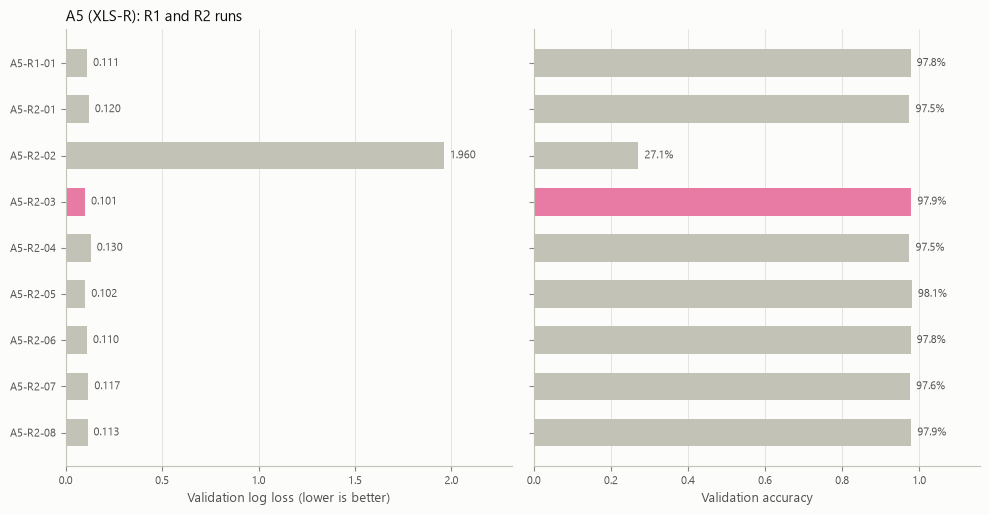

,change,val_logloss,val_acc,val_macro_f1,ece,tisa/sita,nne/nane,minutes
exp_id,,,,,,,,
A5-R1-01,"first A5 run: XLS-R-300M fine-tuned on the raw waveform (feature encoder frozen), no augmentation",0.111,97.8%,0.978,0.016,1.0%,1.0%,13.7
A5-R2-01,"wav2vec2-base (95M, English-only pretraining) instead of XLS-R-300M (128 languages incl. Swahili)",0.120,97.5%,0.975,0.020,1.0%,1.0%,5.7
A5-R2-02,frozen encoder: train only the classification head,1.960,27.1%,0.233,0.075,10.5%,5.8%,4.8
A5-R2-03,"+ waveform augmentation: time shift, speed 0.9-1.1x, noise at 10-30 dB SNR",0.101,97.9%,0.979,0.012,0.0%,1.0%,12.9
A5-R2-04,1.0 s window instead of 1.5 s,0.130,97.5%,0.975,0.014,0.0%,0.0%,10.9
A5-R2-05,2.0 s window instead of 1.5 s,0.102,98.1%,0.981,0.014,0.0%,0.0%,17.6
A5-R2-06,weighted sum of all Transformer layers instead of the last layer,0.110,97.8%,0.978,0.019,0.0%,0.0%,13.2
A5-R2-07,encoder learning rate 1e-5 instead of 3e-5,0.117,97.6%,0.976,0.019,0.0%,1.0%,13.1
A5-R2-08,encoder learning rate 5e-5 instead of 3e-5,0.113,97.9%,0.979,0.011,0.0%,1.0%,13.0


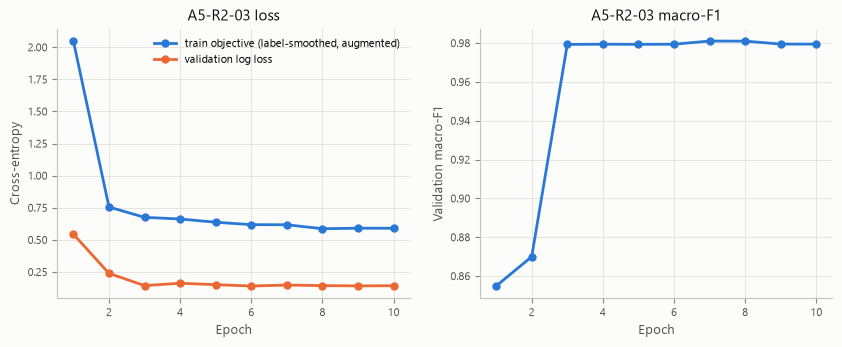

In [7]:
fig = progression_chart(runner.summary("A5"), A5_BEST["exp_id"], MODEL_COLORS["A5"], "A5 (XLS-R): R1 and R2 runs",
                        "a5_r2_progression")
plt.show()
display(ExperimentRunner.styled(runner.summary("A5")))
axes = plot_learning_curves(A5_BEST["extra"]["history"], title=A5_BEST["exp_id"])
save_figure(axes[0].figure, "a5_best_learning_curves")
plt.show()

**Observations → next step (A5, R2)**
- **The final configuration is A5-R2-03:** XLS-R-300M, fine-tuned with the feature encoder frozen, on a 1.5 s window with waveform augmentation, at an encoder learning rate of 3e-5, classifying from the last layer. Log loss 0.101, accuracy 97.9%.
- **Multilingual pretraining helps, but only a little.** XLS-R beats the English-only wav2vec2-base (0.111 vs 0.120; 97.8% vs 97.5%). The gap is small, and the comparison is not clean:
  - The base model is also 3.3× smaller (95M parameters, 12 layers) and 2.4× faster (5.7 vs 13.7 min).
  - XLS-R heard only 91 hours of Swahili.
  - So the gain cannot be put down to the pretraining language alone. An English-only model gets most of the way, which suggests that general speech pretraining matters more here than the language.
- **Fine-tuning the Transformer is essential.** With the encoder frozen and only the head trained, A5 reaches just 27.1% (log loss 1.96) in the same 10 epochs, and its training loss is still falling slowly (2.45 → 1.52). XLS-R's last layer, left as pretrained, does not separate the words linearly. SUPERB's frozen models read a weighted sum of *all* layers, which we did not combine with freezing.
- **Augmentation helps, but less than for A4** (0.111 → 0.101). Time shift, speed perturbation and noise add variation that the pretraining did not already cover.
- **The window:** 1.0 s is worse (0.130), which suggests some words get cut off. 2.0 s ties with 1.5 s (0.102 vs 0.101; 98.1% vs 97.9%) at 36% more compute, so 1.5 s is kept. Unlike A4, A5 gains nothing from the extra context.
- **The weighted layer sum did not help (0.110).** Its weights stayed close to uniform, so under full fine-tuning they do not say which layers matter (see the analysis below). The first run of this step had uninitialised weights, a loading bug that is now fixed; it is archived in `results/failed_runs/`.
- **The learning rate is well chosen:** 1e-5 (0.117) and 5e-5 (0.113) are both worse than 3e-5.
- **Seed noise is tiny for A5** (SD 0.0009, below), so apart from the 2.0 s window every R2 difference here is larger than seed noise. That is unlike A4.

## A5 against A1–A4
All five models are scored on the same 630 validation clips, using the logged predictions of the final A1 (A1-R0-03), A2 (A2-R2-03), A3 (A3-R2-12) and A4 (A4-R2-05).

,run,val log loss,val accuracy,val macro-F1,ECE,tisa/sita,nne/nane,tatu/tano,saba/sita
A1,A1-R0-03,0.725027,0.779365,0.778867,0.035461,0.066667,0.057692,0.084906,0.0
A2,A2-R2-03,0.179942,0.952381,0.952676,0.025088,0.0,0.009615,0.018868,0.009524
A3,A3-R2-12,0.133987,0.969841,0.969908,0.01626,0.0,0.0,0.0,0.009524
A4,A4-R2-05,0.119448,0.971429,0.971477,0.012564,0.0,0.0,0.009434,0.0
A5,A5-R2-03,0.100528,0.979365,0.97942,0.011966,0.0,0.009615,0.0,0.0


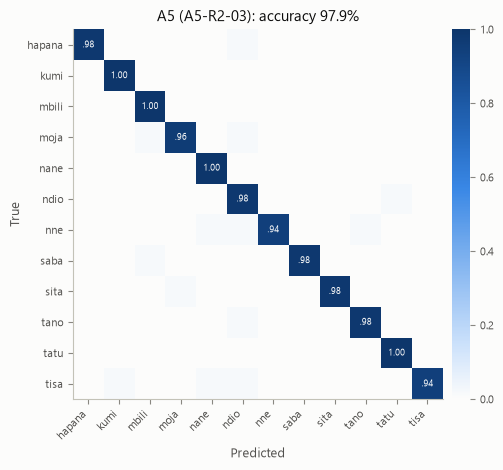

In [8]:
others = {}
for name, exp_id in (("A1", "A1-R0-03"), ("A2", "A2-R2-03"), ("A3", "A3-R2-12"), ("A4", "A4-R2-05")):
    candidates = [base / "predictions" / f"{exp_id}_seed{SEED}_val.csv" for base in (results_dir(), REPO_ROOT / "results")]
    path = next((c for c in candidates if c.exists()), candidates[0])
    if path.exists() and not SMOKE:
        df, probs = load_predictions(path)
        assert (df["id"].to_numpy() == val["id"].to_numpy()).all()
        others[name] = {"exp_id": exp_id, "probs": probs, "metrics": compute_metrics(y_val, probs, NAMES)}
models = {**others, "A5": A5_BEST}
comparison = pd.DataFrame({
    name: {"run": r["exp_id"], "val log loss": r["metrics"]["log_loss"], "val accuracy": r["metrics"]["accuracy"],
           "val macro-F1": r["metrics"]["macro_f1"], "ECE": r["metrics"]["ece"],
           **{f"{a}/{b}": pair_confusion(y_val, r["probs"].argmax(1), NAMES, a, b) for a, b in KEY_PAIRS}}
    for name, r in models.items()}).T
display(comparison)

fig, ax = plt.subplots(figsize=(5.4, 4.8))
plot_confusion_matrix(y_val, A5_BEST["probs"].argmax(1), NAMES, ax=ax,
                      title=f"A5 ({A5_BEST['exp_id']}): accuracy {A5_BEST['metrics']['accuracy']:.1%}")
fig.tight_layout()
save_figure(fig, "a5_confusion")
plt.show()

**Observations → next step (A5 against A1–A4)**
- **A5 is the best model on every metric.**
  - Log loss 0.101, against 0.119 (A4), 0.134 (A3), 0.180 (A2) and 0.725 (A1).
  - Accuracy 97.9%: 13 errors, against 18 (A4) and 19 (A3).
  - Calibration error 0.012, level with A4 (0.013).
- **The sound-alike pairs are solved:** 0% confusion for *tisa/sita*, *tatu/tano* and *saba/sita*, and one clip (1.0%) for *nne/nane*. The lowest recall is on *nne* and *tisa* (94.2%).
- **Pretraining makes the models more confident and better calibrated, but fails on the same hard clips.**
  - All 13 of A5's errors are also A3 errors, and 12 are A4 errors too.
  - Of the 14 clips that both A3 and A4 miss, A5 gets only 2 right (a *tano* and a *nane*).
  - So a floor of about 12 clips (1.9%) defeats every architecture, including a model pretrained on 436K hours.
- **The label-noise candidates hold up.** The two clips flagged in the A4 analysis are confidently wrong for A5 too, with the same word: *nne* heard as *tano* (95%) and *tisa* heard as *nane* (99%). Four very different models now agree on each. On most other hard clips, A5 is unsure (22–43%): it signals its own uncertainty.
- **Caveats.** These are single seed-42 runs, chosen on this validation split, and A5's lead over A4 is 5 clips out of 630. The seed-variance runs below, and McNemar's test on the test split in Phase 7, decide whether the gap is real.
- **→ Next:** Phase 8 listens to the 12 clips that every model gets wrong.

## R3 preparation: seed variance of the final configuration (validation only)
As for A3 and A4, the final configuration is retrained with the three Phase 7 seeds (42, 13, 7) and scored on **validation only**. These runs save the checkpoints that Phase 7 scores once on the test split. The seed-42 run also checks that training on the GPU is deterministic: it should reproduce the R2 result.

In [9]:
R3_SEEDS = (42, 13, 7)
MODEL_KEYS = ("features", "model", "train", "augment")
final_cfg = {k: A5_BEST["params"][k] for k in MODEL_KEYS}
r3 = {}
for seed in R3_SEEDS:
    seed_runner = ExperimentRunner(val, NAMES, member=MEMBER, notebook=NOTEBOOK, seed=seed, rerun=RERUN)
    r3[seed] = seed_runner.run("A5-R3-01", f"final configuration ({A5_BEST['exp_id']}) retrained with seed {seed}",
                               "seed variance on validation; checkpoints for the Phase 7 test evaluation",
                               a5_fit_predict("A5-R3-01", final_cfg, seed=seed, save_checkpoint=True),
                               {**final_cfg, "seed": seed})
seed_table = pd.DataFrame({seed: {"val log loss": r["metrics"]["log_loss"], "val accuracy": r["metrics"]["accuracy"],
                                  "val macro-F1": r["metrics"]["macro_f1"], "ECE": r["metrics"]["ece"]}
                           for seed, r in r3.items()}).T
seed_table.index.name = "seed"
fmt = {"val log loss": "{:.3f}", "val accuracy": "{:.1%}", "val macro-F1": "{:.3f}", "ECE": "{:.3f}"}
display(seed_table.style.format(fmt))
display(seed_table.agg(["mean", "std"]).style.format(fmt))

A5-R3-01 [reused] log loss 0.101 · acc 97.9% · macro-F1 0.979 · ECE 0.012 · tisa/sita 0.0% · 13.0 min


A5-R3-01 [reused] log loss 0.102 · acc 98.1% · macro-F1 0.981 · ECE 0.011 · tisa/sita 0.0% · 13.0 min


A5-R3-01 [reused] log loss 0.102 · acc 97.9% · macro-F1 0.979 · ECE 0.014 · tisa/sita 0.0% · 13.1 min


,val log loss,val accuracy,val macro-F1,ECE
seed,,,,
42,0.101,97.9%,0.979,0.012
13,0.102,98.1%,0.981,0.011
7,0.102,97.9%,0.979,0.014


,val log loss,val accuracy,val macro-F1,ECE
mean,0.102,98.0%,0.980,0.013
std,0.001,0.1%,0.001,0.002


**Observations → next step (A5, seed variance)**
- **A5's lead holds across seeds.** Over seeds 42, 13 and 7, A5 reaches log loss 0.1015 ± 0.0009 and accuracy 98.0% ± 0.1. A3 reaches 0.137 ± 0.004 and A4 0.135 ± 0.023. The gap of 0.035 to A3 is about nine of A3's seed standard deviations, so on validation it is not seed luck.
- **A5 is by far the most stable model.** Its seed spread is 4× smaller than A3's and 25× smaller than A4's. Starting from pretrained weights leaves the seed little to decide: only the head's initialisation, the batch order, dropout and masking.
- **Training is deterministic.** The seed-42 run reproduces A5-R2-03 exactly (0.1005, 97.9%), thanks to the eager attention implementation.
- **→ Next:** Phase 7 scores the three checkpoints once on the test split.
  - The seed-42 checkpoint is kept locally in `checkpoints/`.
  - Seeds 13 and 7 are in the output of version 1 of the A5 Kaggle kernel.
  - They are 1.2 GB each and not committed.

## Analysis (validation clips)
Three views that need only the logged runs, so they re-run without a GPU:
1. **Which layers carry word identity?** Run A5-R2-06 learned a softmax weight for the input embedding and for each Transformer layer.
2. **Does A5 fail on the same clips as A3 and A4?** Errors shared by very different architectures point to hard, unusual or mislabelled clips rather than to a model.
3. **What does A5 cost?** Parameters and training time against A3 and A4.

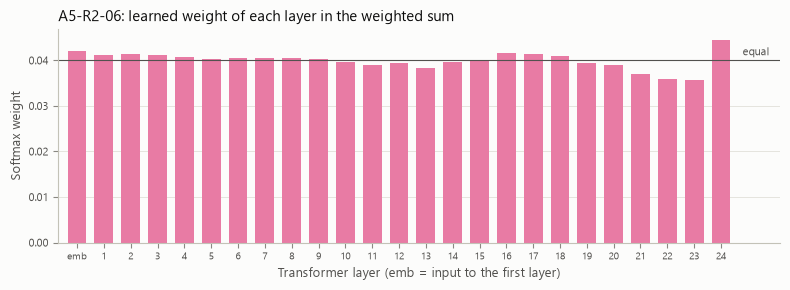

largest weights: {'layer 24': 0.045, 'emb': 0.042, 'layer 16': 0.042}


In [10]:
def find_metrics(exp_id, seed=SEED):
    candidates = [base / "metrics" / f"{exp_id}_seed{seed}_val.json" for base in (results_dir(), REPO_ROOT / "results")]
    return json.loads(next(c for c in candidates if c.exists()).read_text(encoding="utf-8"))


weights = find_metrics("A5-R2-06")["extra"].get("layer_weights")
if weights:
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.bar(np.arange(len(weights)), weights, width=0.7, color=MODEL_COLORS["A5"])
    ax.axhline(1 / len(weights), color=INK_SECONDARY, lw=0.8)
    ax.set_xlim(-0.7, len(weights) + 1.2)                  # room at the right for the label
    ax.annotate("equal", (len(weights) - 0.4, 1 / len(weights)), xytext=(4, 2), textcoords="offset points",
                ha="left", va="bottom", fontsize=8, color=INK_SECONDARY)
    ax.set_xticks(np.arange(len(weights)), ["emb"] + [str(i) for i in range(1, len(weights))], fontsize=7)
    ax.set_xlabel("Transformer layer (emb = input to the first layer)")
    ax.set_ylabel("Softmax weight")
    ax.grid(axis="x", visible=False)
    ax.set_title("A5-R2-06: learned weight of each layer in the weighted sum", loc="left")
    fig.tight_layout()
    save_figure(fig, "a5_layer_weights")
    plt.show()
    top = np.argsort(weights)[::-1][:3]
    print("largest weights:", {("emb" if i == 0 else f"layer {i}"): round(weights[i], 3) for i in top})

In [11]:
wrong = {name: r["probs"].argmax(1) != y_val for name, r in models.items()}
if not SMOKE:
    e5 = wrong["A5"]
    print(f"A5 errors {e5.sum()} · shared with A3 {np.sum(e5 & wrong['A3'])} · with A4 {np.sum(e5 & wrong['A4'])} · "
          f"with both {np.sum(e5 & wrong['A3'] & wrong['A4'])} · A3 and A4 both wrong {np.sum(wrong['A3'] & wrong['A4'])}")
    hard = np.where(wrong["A3"] & wrong["A4"])[0]
    rows = [{"id": val["id"].iloc[i], "true": NAMES[y_val[i]],
             **{f"{n} → (conf)": f"{NAMES[models[n]['probs'][i].argmax()]} ({models[n]['probs'][i].max():.0%})"
                for n in ("A2", "A3", "A4", "A5")}} for i in hard]
    display(pd.DataFrame(rows).style.hide(axis="index").set_caption("Clips that both A3 and A4 get wrong"))

A5 errors 13 · shared with A3 13 · with A4 12 · with both 12 · A3 and A4 both wrong 14


id,true,A2 → (conf),A3 → (conf),A4 → (conf),A5 → (conf)
id_v7wh07s88fzy.wav,hapana,ndio (57%),nne (57%),ndio (78%),ndio (90%)
id_1a8vrokrnq9z.wav,nne,hapana (53%),tatu (27%),tisa (25%),nane (98%)
id_6hq0l1h5mc7n.wav,tano,mbili (27%),moja (94%),moja (41%),tano (96%)
id_tuptx3hjv00w.wav,moja,tatu (77%),hapana (27%),kumi (17%),mbili (23%)
id_e8ul9vf9y9p9.wav,sita,saba (52%),saba (59%),hapana (41%),moja (42%)
id_5degcjdtdfwz.wav,saba,hapana (67%),ndio (50%),ndio (56%),mbili (82%)
id_31m65hpbvm02.wav,tisa,nane (57%),nane (97%),nane (91%),nane (99%)
id_zlfye2qpp812.wav,ndio,saba (23%),moja (80%),hapana (42%),tatu (43%)
id_jcyyd4s6alr0.wav,moja,hapana (22%),hapana (24%),mbili (25%),ndio (22%)
id_kd6i4g770kdy.wav,nane,nane (60%),tano (89%),tano (70%),nane (99%)


In [12]:
def run_cost(exp_id, seed=SEED):
    run = next((base / "runs" / f"{exp_id}_seed{seed}.json" for base in (results_dir(), REPO_ROOT / "results")
                if (base / "runs" / f"{exp_id}_seed{seed}.json").exists()), None)
    rec = json.loads(run.read_text(encoding="utf-8")) if run else {}
    extra = find_metrics(exp_id, seed)["extra"]
    return {"run": exp_id, "parameters": extra.get("n_params"), "trained parameters": extra.get("n_trainable", extra.get("n_params")),
            "epochs": extra.get("epochs_run"), "train minutes": float(rec.get("train_time_min", np.nan)), "device": rec.get("gpu")}


if not SMOKE:
    cost = pd.DataFrame({"A3": run_cost("A3-R2-12"), "A4": run_cost("A4-R2-05"), "A5": run_cost(A5_BEST["exp_id"])}).T
    display(cost.style.format({"parameters": "{:,.0f}", "trained parameters": "{:,.0f}", "train minutes": "{:.1f}"}))

,run,parameters,trained parameters,epochs,train minutes,device
A3,A3-R2-12,"855,052","855,052",29,0.5,Tesla T4
A4,A4-R2-05,"149,988","149,988",32,1.3,Tesla T4
A5,A5-R2-03,"315,704,204","311,494,028",10,12.9,Tesla T4


**Observations → next step (A5 analysis)**
- **The learned layer weights stayed close to uniform.** They range from 0.036 to 0.045, against 0.040 for equal weights. The last layer is slightly highest (0.045), followed by the input embedding and layer 16 (0.042); layers 21–23 are lowest (0.036).
  - Because the whole Transformer is fine-tuned, the layers adapt to the weighting rather than the weighting picking out layers. So this run does not show where word identity sits in the *pretrained* model.
  - A frozen probe of each layer, as in SUPERB, would answer that. It is left as future work, together with the frozen weighted sum that R2 did not test.
- **The errors are shared across architectures.** Every one of A5's 13 errors is also an A3 error, and 12 are also A4 errors. The table lists the 14 clips that A3 and A4 both miss:
  - On most of them the models disagree about the wrong word, and A5 is unsure (22–43%). That points to unclear or unusual recordings.
  - On two, all four models give the same wrong word: *nne* → *tano*, and *tisa* → *nane*. A3, A4 and A5 do so with 91–100% confidence. Those are the strongest candidates for label errors.
- **Cost against accuracy:**
  - A5 has 316M parameters, 2,100× A4's 150K and 370× A3's 855K.
  - A run takes 12.9 min on the T4, against 1.3 min for A4 and 0.5 min for A3.
  - That buys 0.019 log loss and 5 clips over A4. For on-device or phone-line use, A4 is the efficient choice, and A5 the accurate one. Phase 7 adds CPU inference time.
- **→ Next:** the temporal-order stress test (notebook 07) now includes A5. Phase 7 scores the test split.

## Save the selected configuration

In [13]:
cfg_out = {"approach": "A5", "exp_id": A5_BEST["exp_id"], "selected_by": "lowest validation log loss over rounds R1 and R2",
           "checkpoints": "A5-R3-01_seed{42,13,7}.pt (the R2 runs save none: 1.2 GB each)",
           "params": A5_BEST["params"],
           "extra": {k: v for k, v in A5_BEST["extra"].items() if k != "history"},
           "val": {k: round(A5_BEST["metrics"][k], 4) for k in ("log_loss", "accuracy", "macro_f1", "ece")}}
path = (results_dir() if SMOKE else CONFIGS_DIR) / "a5_best.yaml"   # smoke runs never touch configs/
path.write_text(yaml.safe_dump(json.loads(json.dumps(cfg_out, default=float)), sort_keys=False), encoding="utf-8")
print("wrote", path.relative_to(REPO_ROOT) if path.is_relative_to(REPO_ROOT) else path)
table = build_experiment_table()
display(table[table.exp_id.str.startswith("A5")][["exp_id", "change_vs_previous", "val_logloss", "val_acc",
                                                  "val_macro_f1", "train_time_min", "gpu"]])

wrote configs\a5_best.yaml


,exp_id,change_vs_previous,val_logloss,val_acc,val_macro_f1,train_time_min,gpu
52,A5-R1-01,first A5 run: XLS-R-300M fine-tuned on the raw...,0.1109,0.9778,0.9778,13.7119,Tesla T4
53,A5-R2-01,"wav2vec2-base (95M, English-only pretraining) ...",0.1200,0.9746,0.9747,5.6967,Tesla T4
54,A5-R2-02,frozen encoder: train only the classification ...,1.9602,0.2714,0.2330,4.7556,Tesla T4
55,A5-R2-03,"+ waveform augmentation: time shift, speed 0.9...",0.1005,0.9794,0.9794,12.9302,Tesla T4
56,A5-R2-04,1.0 s window instead of 1.5 s,0.1300,0.9746,0.9748,10.9078,Tesla T4
57,A5-R2-05,2.0 s window instead of 1.5 s,0.1016,0.9810,0.9810,17.5796,Tesla T4
58,A5-R2-06,weighted sum of all Transformer layers instead...,0.1103,0.9778,0.9778,13.2367,Tesla T4
59,A5-R2-07,encoder learning rate 1e-5 instead of 3e-5,0.1175,0.9762,0.9764,13.0511,Tesla T4
60,A5-R2-08,encoder learning rate 5e-5 instead of 3e-5,0.1130,0.9794,0.9793,13.0213,Tesla T4
61,A5-R3-01,final configuration (A5-R2-03) retrained with ...,0.1023,0.9794,0.9794,13.0691,Tesla T4
